In [13]:
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import jaccard_score
import seaborn as sns
import pandas as pd

import matplotlib as mpl
from matplotlib.ticker import FuncFormatter


import marsilea as ma

In [2]:
adata = sc.read_h5ad('/data/users/zhoutao3/online/07.3d/Script/0314/adata.noMenings.h5ad')
adata= adata[~adata.obs['region'].isin(['ventricles_I',
 'ventricles_II',
 'ventricles_III',
 'ventricles_IV'])]

In [3]:
adatas = []
for i in set(adata.obs['slices']):
    temp = adata[adata.obs['slices'] == i].copy()
    sc.pp.normalize_total(temp)
    sc.pp.log1p(temp)
    sc.pp.scale(temp, zero_center=False, max_value=10)
    adatas.append(temp)
adata = ad.concat(adatas)

In [4]:
# adata = adata[adata.obs.sample(frac = 0.1).index].copy()
# adata

In [5]:
sc.tl.rank_genes_groups(adata, 'region', method = 'wilcoxon', pts = True)

/opt/software/python/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/opt/software/python/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/opt/software/python/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:401: PerformanceWarning: DataFrame is highly fragmented. 

In [7]:
dic = {}
for i in set(adata.obs['region']):
    temp = sc.get.rank_genes_groups_df(adata, group = str(i))
    temp = temp[temp['logfoldchanges']>1]
    temp = temp.sort_values('logfoldchanges', ascending = False)
    dic[str(i)] = temp[:50]['names'].tolist()

In [14]:
cluster_ids = list(dic.keys())
num_clusters = len(cluster_ids)
jaccard_matrix = np.zeros((num_clusters, num_clusters))
for i, cluster_id_i in enumerate(cluster_ids):
    for j, cluster_id_j in enumerate(cluster_ids):
        genes_i = set(dic[cluster_id_i])
        genes_j = set(dic[cluster_id_j])
        if len(genes_i.union(genes_j)) > 0:
            jaccard_sim = len(genes_i.intersection(genes_j)) / len(genes_i.union(genes_j))
        else:
            jaccard_sim = 0
        jaccard_matrix[int(i), int(j)] = jaccard_sim

jaccard_df = pd.DataFrame(jaccard_matrix, index=cluster_ids, columns=cluster_ids)

In [15]:
orders = ['cerebral', 'olfactory_bulb', 'primordium_hippocampi', 'preoptic_region', 'Striatum', 'dorsal_sac', 'commissura_interbulbaris', # #B6282C
'hypothalami_nucleus', 'corpus_geniculatum_laterale', 'pineal_gland', 'tuberculum_posterius', 'ganglia_habenulae', # #E7CF24
          'thalamus', 'fasciculus_retroflexus', 'commissura_posterior', 'neurohypophysis', 'parapineal_organ', 'nervus_pinealis',  # #E7CF24
'tectum_mesencephali', 'nucleus_tegmentalis_lateralis', 'nucleus_interpeduncularis', 'nucleus_reticularis_mesencephali', # #0C6CB2
'cerebellum_area', 'nucleus_cerebelli',  # #852482
'nucleus_of_the_radix_descendens_nervi_trigemini', 'areae_octavolateralis', 'motor_nucleus_of_VII', 'motor_nucleus_of_V', # #B50F58
          'lobus_vagi', 'spain_cord', 'nucleus_of_X', 'middle_superior_rhombencephalic_reticular_centre', 'inferior_rhombencephalic_reticular_centres',# #B50F58
          'superior_rhombencephalic_reticular_centre', 'griseum_centrale_rhombencephali',  # #B50F58
'ependyma', # #A4A7A8
          'choroid_plexus',] # #691317]
jaccard_df = jaccard_df.reindex(index=orders, columns=orders)

In [16]:
lineage_colors = ['#B6282C', '#B6282C', '#B6282C', '#B6282C', '#B6282C', '#B6282C', '#B6282C', # #B6282C
'#E7CF24', '#E7CF24', '#E7CF24', '#E7CF24', '#E7CF24', # #E7CF24
          '#E7CF24', '#E7CF24', '#E7CF24', '#E7CF24', '#E7CF24', '#E7CF24',  # #E7CF24
'#0C6CB2', '#0C6CB2', '#0C6CB2', '#0C6CB2', # #0C6CB2
'#852482', '#852482',  # #852482
'#B50F58', '#B50F58', '#B50F58', '#B50F58', # #B50F58
          '#B50F58', '#B50F58', '#B50F58', '#B50F58', '#B50F58',# #B50F58
          '#B50F58', '#B50F58',  # #B50F58
'#A4A7A8', # #A4A7A8
          '#691317',] # #691317]

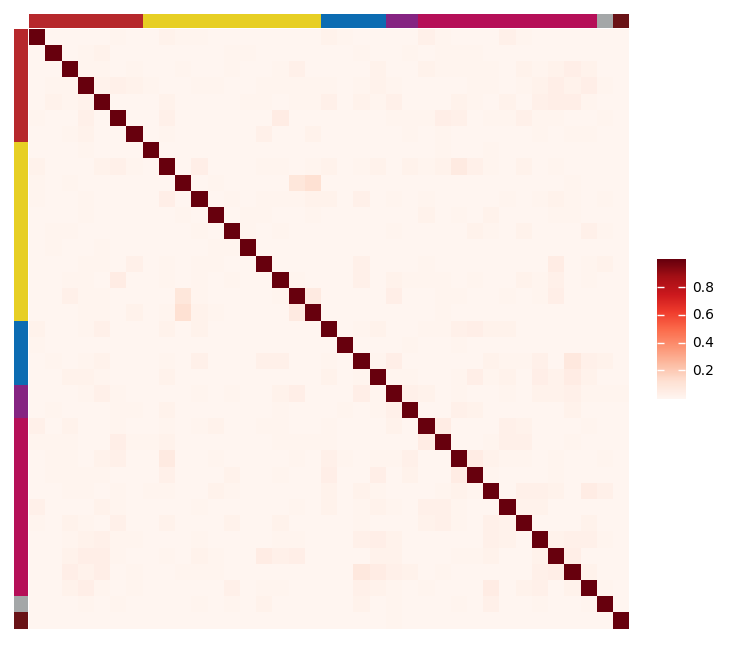

In [30]:
gene_profile = ma.Heatmap(
        jaccard_df,
        # color=dataset["gene_exp_matrix"],
        height=6,
        width=6,
        # cluster_data=cluster_data,
        # marker="P",
        cmap="Reds",
    )
# gene_profile.group_rows(lineage_cells, order=lineage)
gene_profile.group_rows(orders, order=orders,spacing = 0)
gene_profile.add_left(ma.plotter.Chunk(texts = [' ' for i in range(len(orders))], 
                                       padding=0, 
                                       fill_colors = lineage_colors, 
                                       borderwidth = 0),
                      pad=0.01)
gene_profile.group_cols(orders, order=orders,spacing = 0)
gene_profile.add_top(ma.plotter.Chunk(texts = [' ' for i in range(len(orders))], 
                                       padding=0, 
                                       fill_colors = lineage_colors, 
                                       borderwidth = 0),
                      pad=0.01)
# gene_profile.add_dendrogram(
#     "left",
#     method="ward",
#     colors=lineage_colors,
#     meta_color="#451952",
#     linewidth=1.5,
# )
gene_profile.add_legends("right", stack_size=1, stack_by="column", align_stacks="top")
gene_profile.render()
# gene_profile.save("jaccard.png")

plt.savefig("jaccard.pdf", bbox_inches="tight")

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
adata

AnnData object with n_obs × n_vars = 427563 × 17897
    obs: 'area', 'x', 'y', 'region', 'n_counts', 'slices', 'batch', 'z', 'cluster', 'level1', 'level0', 'level-1', 'new_cluster', 'new_cluster.0'
    uns: 'rank_genes_groups'
    obsm: '3d_align_spatial', '3d_align_spatial_confine', 'Nonrigid_align_spatial', 'Rigid_align_spatial', 'X_umap', 'align_spatial', 'bbox', 'spatial'

In [35]:
X = adata.X.toarray()
y = adata.obs['region'].tolist()

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X, y)

In [ ]:
y_pred = rf_model.predict(X)